In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

In [2]:
def path_to_array(img_path, target_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)
    return img_array

# Задание 1. Изучение примеров

Перед выполнением лабораторной работы был изучен представленный пример

# Задание 2. Классификация кошек и собак

## Загрузка датасета

In [4]:
train_cat_dog, test_ds_cat_dog = tf.keras.utils.image_dataset_from_directory(
    r"D:\Python\OmGTU\ML\LAB\LAB_8\data\cats_dogs",
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    labels='inferred',
    class_names=None
)

class_names_1 = train_cat_dog.class_names
class_names_1

Found 2000 files belonging to 2 classes.
Using 1600 files for training.
Using 400 files for validation.


['cat', 'dog']

## Аугментация

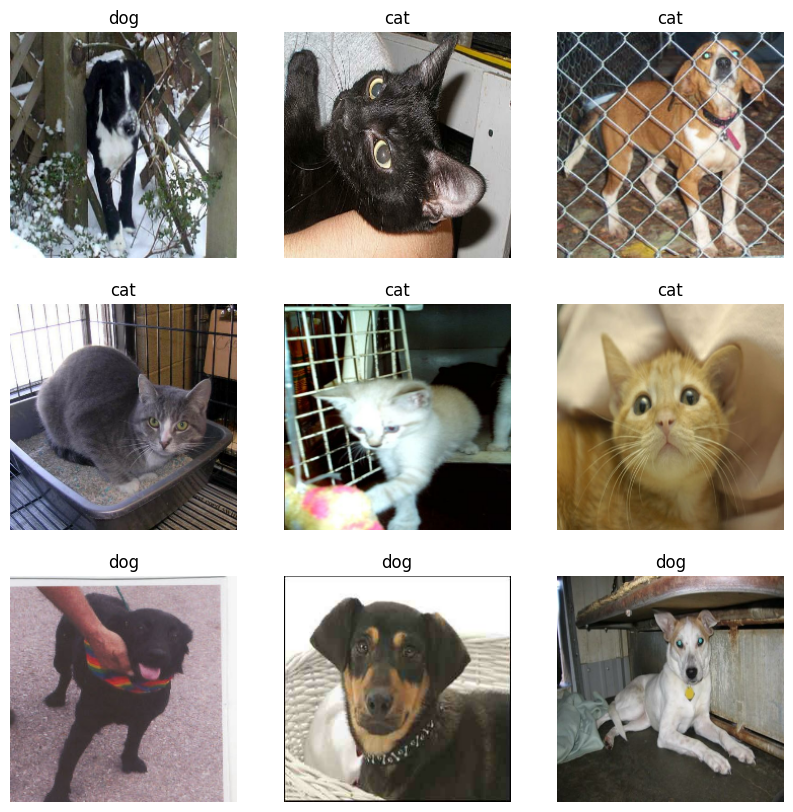

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in train_cat_dog.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_1[labels[i]])
        plt.axis("off")

In [10]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
])

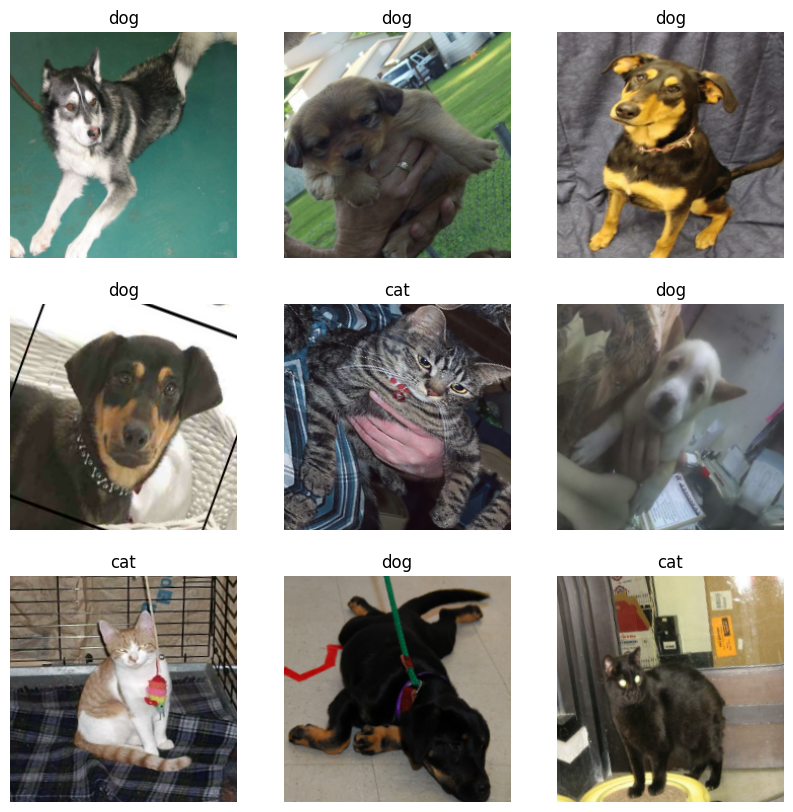

In [12]:
plt.figure(figsize=(10, 10))
for images, labels in train_cat_dog.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names_1[labels[i]])
        plt.axis("off")

## Работа с моделью CNN

In [13]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.layers.Rescaling(1.0 / 255)(x)

x = tf.keras.layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu")(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(2, activation="softmax")(x)

model_cat_dog = tf.keras.models.Model(inputs, outputs)

model_cat_dog.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_cat_dog.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 112, 112, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,738 (1.54 MB)

 Trainable params: 404,354 (1.54 MB)

 Non-trainable params: 384 (1.50 KB)

In [15]:
model_cat_dog.fit(train_cat_dog, epochs=50, validation_data=test_ds_cat_dog)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 472ms/step - accuracy: 0.6789 - loss: 0.5867 - val_accuracy: 0.4600 - val_loss: 0.8006
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 479ms/step - accuracy: 0.6962 - loss: 0.5706 - val_accuracy: 0.4750 - val_loss: 0.7687
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 519ms/step - accuracy: 0.7011 - loss: 0.5812 - val_accuracy: 0.4725 - val_loss: 0.8839
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 505ms/step - accuracy: 0.7187 - loss: 0.5617 - val_accuracy: 0.4800 - val_loss: 0.9257
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 558ms/step - accuracy: 0.7097 - loss: 0.5521 - val_accuracy: 0.5075 - val_loss: 0.8308
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 533ms/step - accuracy: 0.7176 - loss: 0.5383 - val_accuracy: 0.5050 - val_loss: 0.8988
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 28s 551ms/step - accuracy: 0.7212 - loss: 0.5334 - val_accuracy: 0.5300 - val_loss: 0.8127
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 520ms/step - accuracy: 0.7227 - loss: 0.5358 - val_accu

In [ ]:
model_cat_dog.save(r'models\cat_dog.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


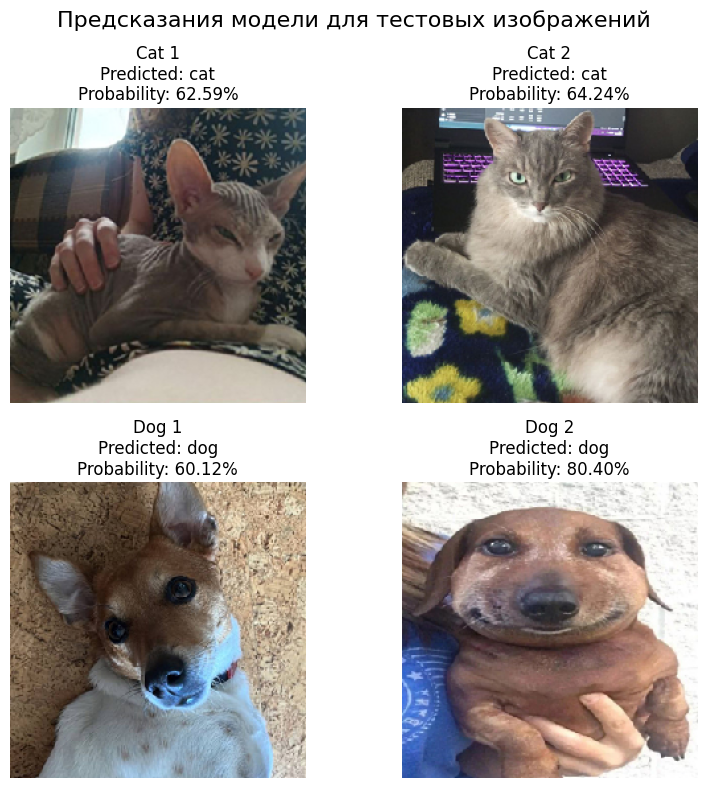

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle('Предсказания модели для тестовых изображений', fontsize=16)

for i, animal in enumerate(['cat', 'dog']):
    for j, ind in enumerate(range(1, 3)):
        path = fr'D:\Python\OmGTU\ML\LAB\LAB_8\data\tests\cats_dogs\test_{animal}_{ind}.jpg'

        img_array = path_to_array(path)
        predictions = model_cat_dog.predict(img_array)
        predicted_class = class_names_1[np.argmax(predictions)]
        prob = np.max(predictions)

        ax = axes[i, j]
        ax.imshow(img_array[0] / 255.0)
        ax.axis('off')

        title = f'{animal.capitalize()} {ind}\nPredicted: {predicted_class}\nProbability: {prob:.2%}'
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [3]:
model_cat_dog = tf.keras.models.load_model(r'models\cat_dog.keras')

In [6]:
test_loss, test_accuracy = model_cat_dog.evaluate(test_ds_cat_dog)
train_loss, train_accuracy = model_cat_dog.evaluate(train_cat_dog)
print(f"Test Accuracy: {test_accuracy:.4f} | Test Loss: {test_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f} | Train Loss: {train_loss:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.7805 - loss: 0.4872
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.8665 - loss: 0.3515
Test Accuracy: 0.7650 | Test Loss: 0.5155
Train Accuracy: 0.8569 | Train Loss: 0.3503


## Вывод

Я получил нейросеть свёрточной архитектуры, которая с точностью **76%** определяет _кошка_ или _собака_ изображена на фотографии.

**О ходе выполнения:**

Данные были разбиты на _тренировочные_ и _тестовые_, а так же были сохранены _названия классов_, для лучшей интерпретации предсказаний.

**Об архитектуре модели:**
1. Слои модели:
    - 3 свёрточных слоя _(извлекают признаки из изображений с ядрами 3×3)_
    - 2 слоя MaxPooling _(уменьшают размерность карт признаков в 2 раза)_  
    - 2 слоя BatchNormalization _(стабилизируют обучение, ускоряют сходимость)_  
    - 1 слой GlobalAveragePooling _(заменяет Flatten, сохраняет пространственные отношения)_  
    - 2 полносвязных слоя _(анализируют извлечённые признаки)_  
    - 1 слой Dropout _(регуляризация для борьбы с переобучением)_  
    
2. Входные данные:
    - Изображения размером **224×224 пикселя** в **RGB-формате** (3 канала)  
    - Автоматическая нормализация (**Rescaling** 1./255)  

3. Выходные данные:
**2 нейрона с softmax** (вероятности принадлежности к классам "кошка"/"собака")  

4. Дополнительные особенности:  
    - Встроенный **аугментационный блок** (RandomFlip, RandomRotation)  
    - Прогрессивное уменьшение размерности:  
    `224×224 → 112×112 → 56×56 → 28×28 → 14×14 → 256-D вектор → 128-D → 2-D`  

5. Оптимизационные механизмы:  
    - Пакетная нормализация после каждой свёртки  
    - Глобальный пулинг вместо Flatten  
    - Dropout 50% перед классификатором  

`[Input Image] → [Augmentation] → [Conv → Pool → BN]×2 → [Conv] → [GAP] → [Dense] → [Dropout] → [Output]`

Архитектура оптимальна для задач бинарной классификации изображений среднего разрешения, но может потребовать увеличения глубины для сложных датасетов.

In [46]:
model_cat_dog.save(r'models\cat_dog.keras')

# Задание 3. Классификация динозавров

## Загрузка датасетов

In [3]:
train_dino, test_dino = tf.keras.utils.image_dataset_from_directory(
    r"D:\Python\OmGTU\ML\LAB\LAB_8\data\caltech",
    validation_split=0.2,
    subset="both",
    seed=42,
    image_size=(224,224),
    batch_size=16,
    labels='inferred',
    class_names=None
)

class_names_2 = train_dino.class_names
class_names_2

Found 161 files belonging to 3 classes.
Using 129 files for training.
Using 32 files for validation.


['brontosaurus', 'rhinoceros', 'stegosaurus']

## Аугментация

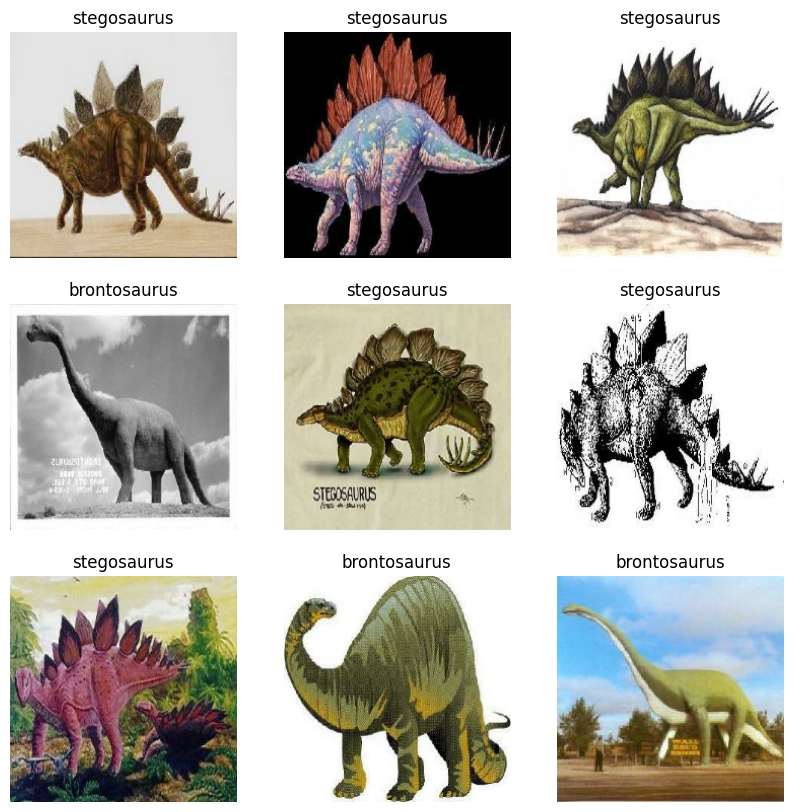

In [6]:
plt.figure(figsize=(10, 10))
for images, labels in train_dino.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_2[labels[i]])
        plt.axis("off")

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3),
])

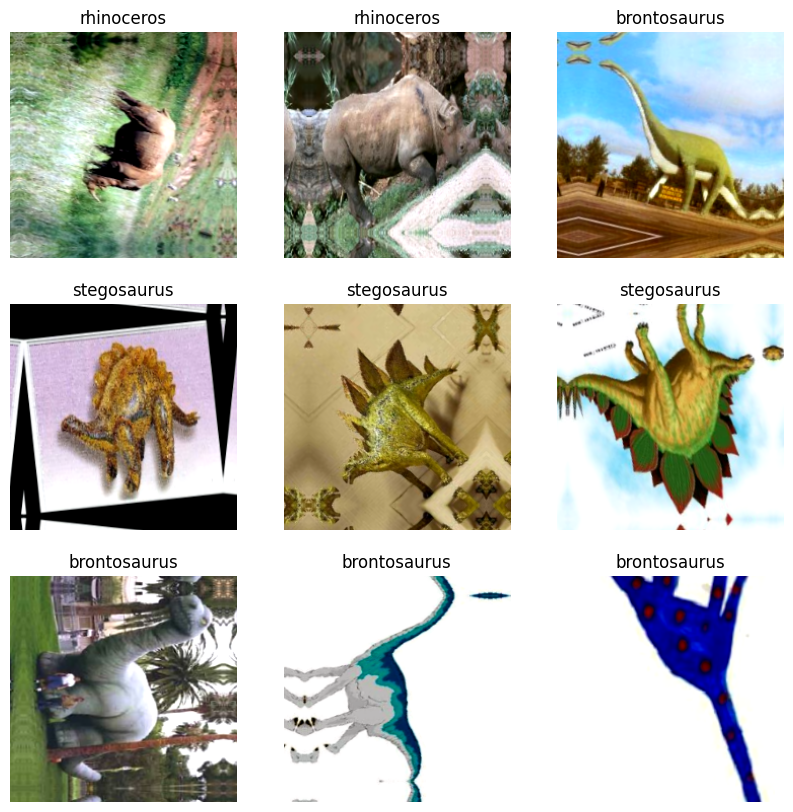

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_dino.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names_2[labels[i]])
        plt.axis("off")

In [9]:
train_dino_aug = train_dino.map(lambda img, label: (data_augmentation(img), label))

## Работа с моделью CNN

### VGG19

In [8]:
vgg = tf.keras.applications.VGG19(weights='imagenet', include_top=True)
vgg.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 143,667,240 (548.05 MB)

 Trainable params: 143,667,240 (548.05 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
vgg_1 = tf.keras.models.clone_model(vgg)
vgg_1.set_weights(vgg.get_weights())

inp = vgg_1.input
classification_layer = tf.keras.layers.Dense(3, activation='softmax')
out = classification_layer(vgg_1.layers[-2].output)
vgg_simple = tf.keras.Model(inp, out)

for layer in vgg_simple.layers:
    layer.trainable = False
vgg_simple.layers[-1].trainable = True

vgg_simple.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
vgg_simple.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_5 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,582,531 (532.47 MB)

 Trainable params: 12,291 (48.01 KB)

 Non-trainable params: 139,570,240 (532.42 MB)

In [10]:
vgg_2 = tf.keras.models.clone_model(vgg)
vgg_2.set_weights(vgg.get_weights())

inp = vgg_2.input
classification_layer = tf.keras.layers.Dense(3, activation='softmax')
out = classification_layer(vgg_2.layers[-2].output)
vgg_difficult = tf.keras.Model(inp, out)

for layer in vgg_difficult.layers:
    layer.trainable = False
vgg_difficult.layers[-1].trainable = True
vgg_difficult.layers[-2].trainable = True

vgg_difficult.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
vgg_difficult.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_5 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,582,531 (532.47 MB)

 Trainable params: 16,793,603 (64.06 MB)

 Non-trainable params: 122,788,928 (468.40 MB)

In [34]:
vgg_simple.fit(train_dino_aug, epochs=1, validation_data=test_dino)

9/9 ━━━━━━━━━━━━━━━━━━━━ 50s 6s/step - accuracy: 0.9296 - loss: 0.2380 - val_accuracy: 0.9062 - val_loss: 0.3711


In [36]:
test_loss, test_accuracy = vgg_simple.evaluate(test_dino)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.8958 - loss: 0.4052
Test Accuracy: 0.9062
Test Loss: 0.3711


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step


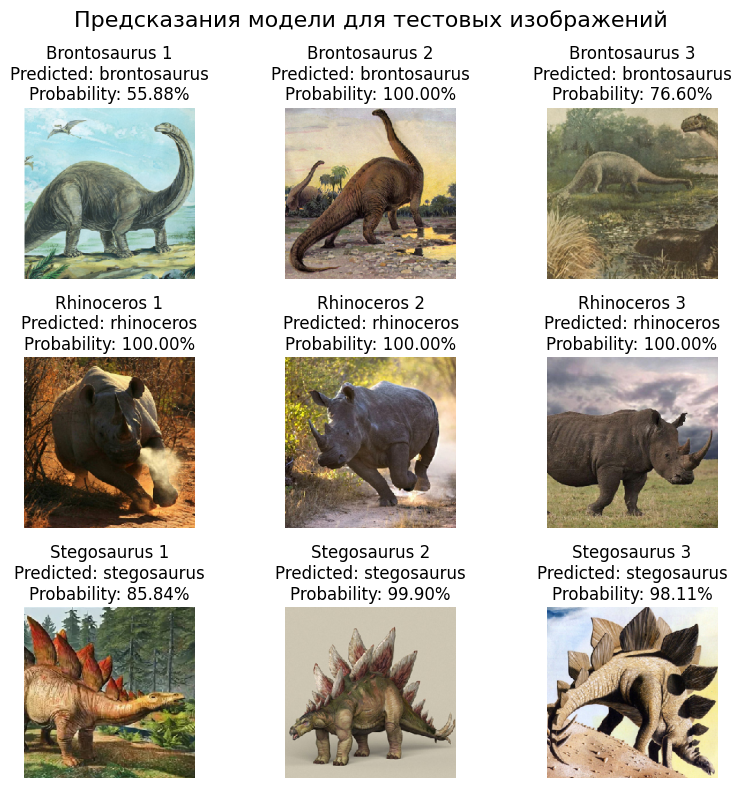

In [35]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Предсказания модели для тестовых изображений', fontsize=16)

for i, animal in enumerate(['brontosaurus', 'rhinoceros', 'stegosaurus']):
    for j, ind in enumerate(range(1, 4)):
        path = fr'D:\Python\OmGTU\ML\LAB\LAB_8\data\tests\dinos\test_{animal}_{ind}.jpg'

        img_array = path_to_array(path)
        predictions = vgg_simple.predict(img_array)
        predicted_class = class_names_2[np.argmax(predictions)]
        prob = np.max(predictions)

        ax = axes[i, j]
        ax.imshow(img_array[0] / 255.0)
        ax.axis('off')

        title = f'{animal.capitalize()} {ind}\nPredicted: {predicted_class}\nProbability: {prob:.2%}'
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [38]:
vgg_simple.save(r'models\vgg_simple.keras')

In [29]:
vgg_difficult.fit(train_dino_aug, epochs=1, validation_data=test_dino)

9/9 ━━━━━━━━━━━━━━━━━━━━ 49s 5s/step - accuracy: 0.9554 - loss: 0.7180 - val_accuracy: 0.9062 - val_loss: 1.7210


In [37]:
test_loss, test_accuracy = vgg_difficult.evaluate(test_dino)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 5s/step - accuracy: 0.9167 - loss: 1.6035
Test Accuracy: 0.9062
Test Loss: 1.7210


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 502ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step


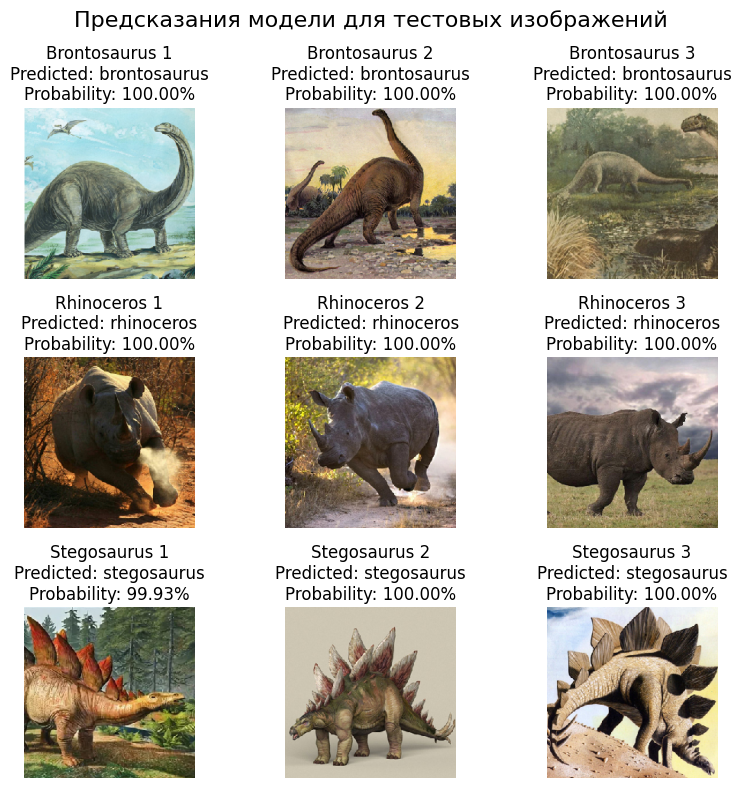

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Предсказания модели для тестовых изображений', fontsize=16)

for i, animal in enumerate(['brontosaurus', 'rhinoceros', 'stegosaurus']):
    for j, ind in enumerate(range(1, 4)):
        path = fr'D:\Python\OmGTU\ML\LAB\LAB_8\data\tests\dinos\test_{animal}_{ind}.jpg'

        img_array = path_to_array(path)
        predictions = vgg_difficult.predict(img_array)
        predicted_class = class_names_2[np.argmax(predictions)]
        prob = np.max(predictions)

        ax = axes[i, j]
        ax.imshow(img_array[0] / 255.0)
        ax.axis('off')

        title = f'{animal.capitalize()} {ind}\nPredicted: {predicted_class}\nProbability: {prob:.2%}'
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [39]:
vgg_difficult.save(r'models\vgg_difficult.keras')

### InceptionV3

In [10]:
def preprocess(image, label=None):
    image = tf.image.resize(image, [299, 299])
    image = tf.keras.applications.inception_v3.preprocess_input(image)
    return image if label is None else (image, label)

def path_to_array_interception(img_path):
    img = tf.keras.preprocessing.image.load_img(img_path)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    return tf.expand_dims(img_array, axis=0)

In [11]:
train_dino_299 = train_dino_aug.map(preprocess)
test_dino_299 = test_dino.map(preprocess)

In [12]:
incept = tf.keras.applications.InceptionV3(weights='imagenet', include_top=True)
incept.summary()

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,851,784 (90.99 MB)

 Trainable params: 23,817,352 (90.86 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [13]:
incept_1 = tf.keras.models.clone_model(incept)
incept_1.set_weights(incept.get_weights())

inp = incept_1.input
classification_layer = tf.keras.layers.Dense(3, activation='softmax')
out = classification_layer(incept_1.layers[-2].output)
incept_simple = tf.keras.Model(inp, out)

for layer in incept_simple.layers:
    layer.trainable = False
incept_simple.layers[-1].trainable = True

incept_simple.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

incept_simple.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_5      │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ keras_tensor_5[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,808,931 (83.19 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [41]:
incept_2 = tf.keras.models.clone_model(incept)
incept_2.set_weights(incept.get_weights())

inp = incept_2.input
classification_layer = tf.keras.layers.Dense(3, activation='softmax')

out = classification_layer(incept_2.layers[-2].output)
incept_difficult = tf.keras.Model(inp, out)

for layer in incept_difficult.layers:
    layer.trainable = False
incept_difficult.layers[-1].trainable = True
incept_difficult.get_layer('conv2d_93').trainable = True

incept_difficult.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

incept_difficult.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ keras_tensor_5      │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ keras_tensor_5[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,808,931 (83.19 MB)

 Trainable params: 399,363 (1.52 MB)

 Non-trainable params: 21,409,568 (81.67 MB)

In [37]:
incept_simple.fit(train_dino_299, epochs=1, validation_data=test_dino_299)

9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.9394 - loss: 0.3053 - val_accuracy: 0.9375 - val_loss: 0.2763


In [39]:
test_loss, test_accuracy = incept_simple.evaluate(test_dino_299)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step - accuracy: 0.9375 - loss: 0.2853
Test Accuracy: 0.9375
Test Loss: 0.2763


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


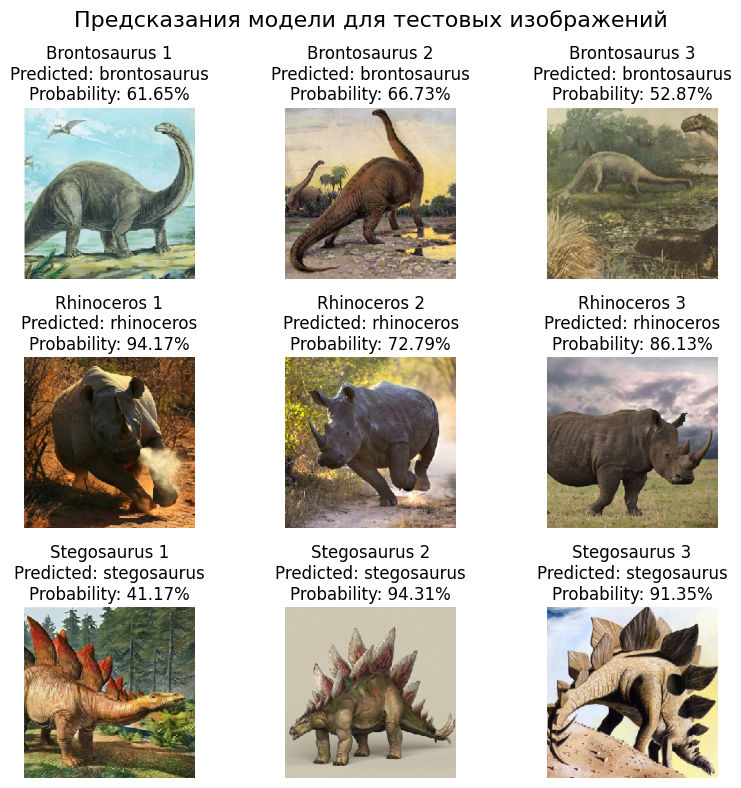

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Предсказания модели для тестовых изображений', fontsize=16)

for i, animal in enumerate(['brontosaurus', 'rhinoceros', 'stegosaurus']):
    for j, ind in enumerate(range(1, 4)):
        path = fr'D:\Python\OmGTU\ML\LAB\LAB_8\data\tests\dinos\test_{animal}_{ind}.jpg'

        img_array = path_to_array(path)
        img_preprocessed = preprocess(img_array)
        predictions = incept_simple.predict(img_preprocessed)
        predicted_class = class_names_2[np.argmax(predictions)]
        prob = np.max(predictions)

        ax = axes[i, j]
        ax.imshow(img_array[0] / 255.0)
        ax.axis('off')

        title = f'{animal.capitalize()} {ind}\nPredicted: {predicted_class}\nProbability: {prob:.2%}'
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
incept_simple.save(r'models\incept_simple.keras')

In [66]:
incept_difficult.fit(train_dino_299, epochs=1, validation_data=test_dino_299)

9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9759 - loss: 0.0723 - val_accuracy: 0.9375 - val_loss: 0.1502


In [68]:
test_loss, test_accuracy = incept_difficult.evaluate(test_dino_299)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.9375 - loss: 0.1527
Test Accuracy: 0.9375
Test Loss: 0.1502


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


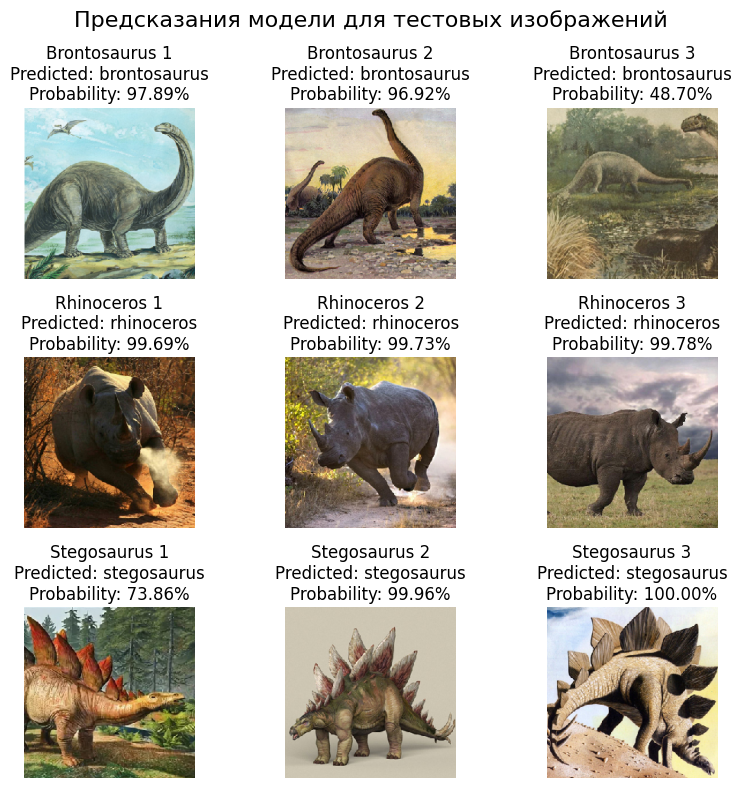

In [67]:
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
fig.suptitle('Предсказания модели для тестовых изображений', fontsize=16)

for i, animal in enumerate(['brontosaurus', 'rhinoceros', 'stegosaurus']):
    for j, ind in enumerate(range(1, 4)):
        path = fr'D:\Python\OmGTU\ML\LAB\LAB_8\data\tests\dinos\test_{animal}_{ind}.jpg'

        img_array = path_to_array(path)
        img_preprocessed = preprocess(img_array)
        predictions = incept_difficult.predict(img_preprocessed)
        predicted_class = class_names_2[np.argmax(predictions)]
        prob = np.max(predictions)

        ax = axes[i, j]
        ax.imshow(img_array[0] / 255.0)
        ax.axis('off')

        title = f'{animal.capitalize()} {ind}\nPredicted: {predicted_class}\nProbability: {prob:.2%}'
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

In [69]:
incept_difficult.save(r'models\incept_difficult.keras')

### Оценка моделей

In [73]:
res_data = []

for model_name in ['vgg_simple', 'vgg_difficult', 'incept_simple', 'incept_difficult']:
    model = tf.keras.models.load_model(f'models\\{model_name}.keras')
    if 'vgg' in model_name:
        test_loss, test_accuracy = model.evaluate(test_dino)
        train_loss, train_accuracy = model.evaluate(train_dino_aug)
    else:
        test_loss, test_accuracy = model.evaluate(test_dino_299)
        train_loss, train_accuracy = model.evaluate(train_dino_299)

    line = pd.Series({'model': model_name,
                      'test_accuracy': round(test_accuracy, 2),
                      'train_accuracy': round(train_accuracy, 2),
                      'test_loss': round(test_loss, 2),
                      'train_loss': round(train_loss, 2)})
    
    res_data.append(line)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step - accuracy: 0.8958 - loss: 0.4052
9/9 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.9002 - loss: 0.2603
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step - accuracy: 0.9167 - loss: 1.6035
9/9 ━━━━━━━━━━━━━━━━━━━━ 43s 5s/step - accuracy: 0.9874 - loss: 0.1801
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9375 - loss: 0.2853
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9227 - loss: 0.2985
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9375 - loss: 0.1527
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9680 - loss: 0.0563


In [74]:
pd.DataFrame(res_data)

,model,test_accuracy,train_accuracy,test_loss,train_loss
0,vgg_simple,0.91,0.91,0.37,0.20
1,vgg_difficult,0.91,0.98,1.72,0.22
2,incept_simple,0.94,0.93,0.28,0.30
3,incept_difficult,0.94,0.98,0.15,0.05


## Вывод

В ходе выполнения задания я получил 4 модели НС архитектуры CNN, лучшими из которых на тестовых изображениях стали модели, унаследовавшие свою архитектуру и веса у **InceptionV3**, что подкрепляет превосходство этой модели над **VGG19** _(по информации в открытых источниках)_